In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import KFold
import numpy as np
import tensorflow as tf
from tensorflow import keras
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)



In [10]:
# 1. Definir las rutas de los archivos CSV preprocesados
path_train = "dfFinalMWB_Train/MWB_TRAIN.csv"
path_test  = "dfFinalMWB_Test/MWB_Test.csv"

# 2. Cargar los datasets
df_train = pd.read_csv(path_train)
df_test  = pd.read_csv(path_test)

# 3. Verificación de carga
print("==============================================")
print("        DATASETS CARGADOS CON ÉXITO           ")
print("==============================================")
print(f"Dimensiones de Train: {df_train.shape[0]} filas, {df_train.shape[1]} columnas")
print(f"Dimensiones de Test:  {df_test.shape[0]} filas, {df_test.shape[1]} columnas")

print("\n--- Tipos de datos en Train ---")
print(df_train.dtypes)

print("\n--- Primeras 5 filas de Train ---")
display(df_train.head())

        DATASETS CARGADOS CON ÉXITO           
Dimensiones de Train: 1157 filas, 30 columnas
Dimensiones de Test:  321 filas, 30 columnas

--- Tipos de datos en Train ---
User_ID                          object
Age                               int64
Gender                           object
Occupation                       object
Relationship_Status              object
Primary_Platform                 object
Daily_Usage_Hours               float64
Platforms_Used_Count              int64
Posts_Per_Week                    int64
Late_Night_Usage                   bool
First_Check_Morning              object
Notifications_Per_Day             int64
FOMO_Score                      float64
Social_Comparison_Score         float64
Validation_Seeking_Score        float64
Scroll_Without_Purpose          float64
Tried_To_Cut_Back                  bool
Failed_To_Cut_Back                 bool
Anxiety_Score                   float64
Depression_Score                float64
Loneliness_Score             

,User_ID,Age,Gender,Occupation,Relationship_Status,Primary_Platform,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Late_Night_Usage,...,Loneliness_Score,Self_Esteem_Score,Sleep_Quality_Score,Sleep_Hours,Productivity_Loss_Score,Offline_Relationship_Quality,Physical_Activity_Hrs_Week,Screen_Free_Time_Hrs,Mental_Wellbeing_Score,Addiction_Level
0,USR00001,30,MALE,WORKING PROFESSIONAL,IN A RELATIONSHIP,YOUTUBE,2.9,4,3,False,...,1.7,6.5,8.5,5.3,3.7,3.8,5.8,3.1,7.3,LOW
1,USR00002,19,MALE,STUDENT,MARRIED,INSTAGRAM,4.8,1,0,True,...,7.0,7.5,7.8,5.5,4.0,1.8,0.9,3.3,4.1,SEVERE
2,USR00003,40,MALE,STUDENT,IN A RELATIONSHIP,YOUTUBE,4.4,4,5,False,...,5.6,5.3,6.3,6.6,5.8,2.8,0.0,1.5,5.6,HIGH
3,USR00007,38,FEMALE,STUDENT,IN A RELATIONSHIP,FACEBOOK,5.0,4,4,True,...,7.2,0.5,4.8,8.2,6.8,5.4,3.2,3.7,5.5,HIGH
4,USR00008,22,FEMALE,UNEMPLOYED,SINGLE,TWITTER/X,3.4,5,2,False,...,3.1,2.9,3.8,10.0,6.8,6.7,2.9,6.6,6.2,MODERATE


In [11]:
# 1. Definir la variable objetivo
# 1. Definir la variable objetivo
le = LabelEncoder()
df_train['Addiction_Level'] = le.fit_transform(df_train['Addiction_Level'])
df_test['Addiction_Level'] = le.transform(df_test['Addiction_Level'])
target_col = "Addiction_Level"

columnas_a_dropear = [
    "User_ID",                 
    "Mental_Wellbeing_Score",         
    "Anxiety_Score",           
    "Depression_Score",       
    "Loneliness_Score",        
    "Self_Esteem_Score",       
    "FOMO_Score",              
    "Social_Comparison_Score", 
    "Validation_Seeking_Score",
    "Productivity_Loss_Score",
    "Sleep_Quality_Score"
]

# 3. Separar X (Características) e y (Variable Objetivo) para TRAIN
X_train = df_train.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_train = df_train[target_col]

# 4. Separar X e y para TEST
X_test = df_test.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_test = df_test[target_col]

# 5. Comprobación
print("==============================================")
print("        SEPARACIÓN Y LIMPIEZA COMPLETADA      ")
print("==============================================")
print(f"Dimensiones de X_train (Predictoras): {X_train.shape}")
print(f"Dimensiones de y_train (Objetivo):    {y_train.shape}")
print(f"Dimensiones de X_test (Predictoras):  {X_test.shape}")
print(f"Dimensiones de y_test (Objetivo):     {y_test.shape}")

print("\nColumnas que usará el modelo para aprender:")
print(list(X_train.columns))

        SEPARACIÓN Y LIMPIEZA COMPLETADA      
Dimensiones de X_train (Predictoras): (1157, 18)
Dimensiones de y_train (Objetivo):    (1157,)
Dimensiones de X_test (Predictoras):  (321, 18)
Dimensiones de y_test (Objetivo):     (321,)

Columnas que usará el modelo para aprender:
['Age', 'Gender', 'Occupation', 'Relationship_Status', 'Primary_Platform', 'Daily_Usage_Hours', 'Platforms_Used_Count', 'Posts_Per_Week', 'Late_Night_Usage', 'First_Check_Morning', 'Notifications_Per_Day', 'Scroll_Without_Purpose', 'Tried_To_Cut_Back', 'Failed_To_Cut_Back', 'Sleep_Hours', 'Offline_Relationship_Quality', 'Physical_Activity_Hrs_Week', 'Screen_Free_Time_Hrs']


In [12]:
# 1. Identificar cuáles son las columnas numéricas
columnas_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns

print(f"Se van a escalar las siguientes columnas numéricas:\n{list(columnas_numericas)}\n")

# 2. Inicializar el StandardScaler
scaler = StandardScaler()

# 3. Ajustar  y transformar
X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

# ==========================================
# 5. Comprobación de que se hizo correctamente
# ==========================================
print("--- Comprobación en TRAIN ---")
print("La media de Train debería ser muy cercana a 0:")
print(X_train[columnas_numericas].mean().round(2))
print("\nLa desviación estándar de Train debería ser 1:")
print(X_train[columnas_numericas].std().round(2))

print("\n--- Primeras filas de X_train escalado ---")
display(X_train.head()) 

Se van a escalar las siguientes columnas numéricas:
['Age', 'Daily_Usage_Hours', 'Platforms_Used_Count', 'Posts_Per_Week', 'Notifications_Per_Day', 'Scroll_Without_Purpose', 'Sleep_Hours', 'Offline_Relationship_Quality', 'Physical_Activity_Hrs_Week', 'Screen_Free_Time_Hrs']

--- Comprobación en TRAIN ---
La media de Train debería ser muy cercana a 0:
Age                            -0.0
Daily_Usage_Hours               0.0
Platforms_Used_Count            0.0
Posts_Per_Week                 -0.0
Notifications_Per_Day          -0.0
Scroll_Without_Purpose          0.0
Sleep_Hours                    -0.0
Offline_Relationship_Quality    0.0
Physical_Activity_Hrs_Week      0.0
Screen_Free_Time_Hrs           -0.0
dtype: float64

La desviación estándar de Train debería ser 1:
Age                             1.0
Daily_Usage_Hours               1.0
Platforms_Used_Count            1.0
Posts_Per_Week                  1.0
Notifications_Per_Day           1.0
Scroll_Without_Purpose          1.0
Sleep_Ho

,Age,Gender,Occupation,Relationship_Status,Primary_Platform,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Late_Night_Usage,First_Check_Morning,Notifications_Per_Day,Scroll_Without_Purpose,Tried_To_Cut_Back,Failed_To_Cut_Back,Sleep_Hours,Offline_Relationship_Quality,Physical_Activity_Hrs_Week,Screen_Free_Time_Hrs
0,0.067334,MALE,WORKING PROFESSIONAL,IN A RELATIONSHIP,YOUTUBE,-0.789127,0.456438,-0.491000,False,WITHIN 5 MIN,0.058735,2.189671,False,False,-0.899325,-0.832606,1.667503,0.072920
1,-1.221326,MALE,STUDENT,MARRIED,INSTAGRAM,0.132625,-1.343900,-2.132871,True,WITHIN 5 MIN,1.544618,1.711265,True,True,-0.753349,-1.821444,-1.272773,0.196357
2,1.238843,MALE,STUDENT,IN A RELATIONSHIP,YOUTUBE,-0.061428,0.456438,0.603580,False,WITHIN 5 MIN,1.878184,0.323886,False,True,0.049521,-1.327025,-1.812824,-0.914570
3,1.004541,FEMALE,STUDENT,IN A RELATIONSHIP,FACEBOOK,0.229652,0.456438,0.056290,True,WITHIN 5 MIN,-1.093583,-1.350537,False,True,1.217331,-0.041536,0.107357,0.443229
4,-0.869873,FEMALE,UNEMPLOYED,SINGLE,TWITTER/X,-0.546561,1.056551,-1.038291,False,WITHIN 5 MIN,0.119383,-0.680768,True,False,2.531118,0.601208,-0.072660,2.233056


In [13]:
# 1. Definir qué columnas son categóricas
columnas_categoricas = ['Gender', 'Occupation', 'Relationship_Status', 'Primary_Platform','First_Check_Morning']

# 2. Aplicar One-Hot Encoding a Train y Test
X_train_codificado = pd.get_dummies(X_train, columns=columnas_categoricas, drop_first=True)
X_test_codificado = pd.get_dummies(X_test, columns=columnas_categoricas, drop_first=True)

# 3. ALINEAR Train y Test (Crucial)
X_train_codificado, X_test_codificado = X_train_codificado.align(X_test_codificado, join='left', axis=1, fill_value=0)

print(f"Columnas finales para entrenar: {X_train_codificado.shape[1]}")

Columnas finales para entrenar: 31


In [15]:
# 1. PREPARACIÓN DE DATOS RÁPIDA PARA OPTUNA
# Dividimos tu X_train_codificado en Train y Validación interna
X_tr, X_val, y_tr, y_val = train_test_split(X_train_codificado, y_train, test_size=0.2, random_state=42)

# Convertimos a Tensores (usando tus variables reales)
X_tr_tensor = torch.tensor(X_tr.astype(np.float32).values, dtype=torch.float32)
y_tr_tensor = torch.tensor(y_tr.astype(np.float32).values, dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val.astype(np.float32).values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.astype(np.float32).values, dtype=torch.float32).unsqueeze(1)

# DataLoader
train_loader = DataLoader(TensorDataset(X_tr_tensor, y_tr_tensor), batch_size=64, shuffle=True)

# 2. DEFINIMOS LA FUNCIÓN DE BÚSQUEDA
def objective(trial):
    # --- A. Optuna "adivina" los hiperparámetros ---
    # Le decimos que pruebe entre 1 y 4 capas ocultas
    n_layers = trial.suggest_int('n_layers', 1, 6) 
    # Que pruebe un dropout entre 10% y 50%
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5) 
    # Que pruebe diferentes tasas de aprendizaje (learning rate)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True) 
    
    # --- B. Construimos la red neuronal dinámicamente ---
    layers = []
    in_features = X_train_codificado.shape[1] # Tus 31 columnas de entrada
    
    for i in range(n_layers):
        # Para cada capa, Optuna decide si pone entre 16 y 128 neuronas
        out_features = trial.suggest_int(f'n_units_l{i}', 16, 128) 
        
        layers.append(nn.Linear(in_features, out_features))
        layers.append(nn.BatchNorm1d(out_features))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout_rate))
        
        in_features = out_features # La salida de esta capa es la entrada de la siguiente
        
    # Capa final de salida (1 neurona para predecir el Mental Wellbeing Score)
    layers.append(nn.Linear(in_features, 1))
    
    # Empaquetamos la red
    model = nn.Sequential(*layers)
    
    # --- C. Entrenamos el modelo ---
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    model.train()
    # Entrenamos solo por 100 épocas para que la búsqueda sea rápida
    for epoch in range(100): 
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            pred = model(batch_X)
            loss = criterion(pred, batch_y)
            loss.backward()
            optimizer.step()
            
    # --- D. Evaluamos qué tan buena fue esta arquitectura ---
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_tensor)
        val_loss = criterion(val_preds, y_val_tensor).item() # Calculamos el error
        
    return val_loss # Le decimos a Optuna que su objetivo es minimizar este error

# 3. EJECUTAMOS LA BÚSQUEDA MÁGICA
print("Iniciando búsqueda de la mejor Red Neuronal...")
study = optuna.create_study(direction='minimize')
# Le pedimos que construya y pruebe 20 redes neuronales distintas
study.optimize(objective, n_trials=50) 

print("\n==============================================")
print("¡BÚSQUEDA TERMINADA! LA MEJOR RED NEURONAL ES:")
print("==============================================")
print(study.best_params)

[I 2026-08-28 06:11:47,855] A new study created in memory with name: no-name-ccce569a-4893-4dcc-94fd-e5a272e9113d


Iniciando búsqueda de la mejor Red Neuronal...


[I 2026-08-28 06:11:51,642] Trial 0 finished with value: 1.3689186573028564 and parameters: {'n_layers': 4, 'dropout_rate': 0.32333944836349426, 'lr': 0.00731842022614067, 'n_units_l0': 33, 'n_units_l1': 48, 'n_units_l2': 95, 'n_units_l3': 118}. Best is trial 0 with value: 1.3689186573028564.
[I 2026-08-28 06:11:54,032] Trial 1 finished with value: 1.085050106048584 and parameters: {'n_layers': 2, 'dropout_rate': 0.27559782131885935, 'lr': 0.00034401539866803964, 'n_units_l0': 19, 'n_units_l1': 72}. Best is trial 1 with value: 1.085050106048584.
[I 2026-08-28 06:11:58,857] Trial 2 finished with value: 1.0971113443374634 and parameters: {'n_layers': 6, 'dropout_rate': 0.31653048147949125, 'lr': 0.0009877409661072207, 'n_units_l0': 23, 'n_units_l1': 81, 'n_units_l2': 25, 'n_units_l3': 120, 'n_units_l4': 75, 'n_units_l5': 67}. Best is trial 1 with value: 1.085050106048584.
[I 2026-08-28 06:12:00,746] Trial 3 finished with value: 1.3192766904830933 and parameters: {'n_layers': 1, 'dropout_


¡BÚSQUEDA TERMINADA! LA MEJOR RED NEURONAL ES:
{'n_layers': 5, 'dropout_rate': 0.4557923746550393, 'lr': 0.00023566092827896352, 'n_units_l0': 64, 'n_units_l1': 35, 'n_units_l2': 74, 'n_units_l3': 102, 'n_units_l4': 46}


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import numpy as np

from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, classification_report


# ==========================================
# 1. DEFINICIÓN DEL MODELO
# ==========================================

class TabularClassificationModel(nn.Module):

    def __init__(self, num_features):

        super(TabularClassificationModel, self).__init__()

        self.network = nn.Sequential(

            # Capa 1
            nn.Linear(num_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.4557923746550393),

            # Capa 2
            nn.Linear(64, 35),
            nn.BatchNorm1d(35),
            nn.ReLU(),
            nn.Dropout(p=0.4557923746550393),

            # Capa 3
            nn.Linear(35, 74),
            nn.BatchNorm1d(74),
            nn.ReLU(),
            nn.Dropout(p=0.4557923746550393),

            # Capa 4
            nn.Linear(74, 102),
            nn.BatchNorm1d(102),
            nn.ReLU(),
            nn.Dropout(p=0.4557923746550393),

            # Capa 5
            nn.Linear(102, 46),
            nn.BatchNorm1d(46),
            nn.ReLU(),
            nn.Dropout(p=0.4557923746550393),

            # ==========================================
            # SALIDA: 4 CLASES
            # ==========================================
            nn.Linear(46, 4)
        )

    def forward(self, x):
        return self.network(x)


# ==========================================
# 2. PREPARACIÓN DE DATOS
# ==========================================

X_tensor = torch.tensor(
    X_train_codificado.astype(np.float32).values,
    dtype=torch.float32
)


y_tensor = torch.tensor(
    y_train.astype(np.int64).values,
    dtype=torch.long
)


# ==========================================
# 3. K-FOLD
# ==========================================

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_accuracy_scores = []
fold_f1_scores = []


# ==========================================
# 4. HIPERPARÁMETROS
# ==========================================

batch_size = 64
max_epochs = 300
patience = 25

learning_rate = 0.00023566092827896352

dropout_rate = 0.4557923746550393


# ==========================================
# 5. ENTRENAMIENTO CON 5-FOLD
# ==========================================

for fold, (train_idx, val_idx) in enumerate(kf.split(X_tensor)):

    print(f"\n--- FOLD {fold + 1} ---")

    # ------------------------------------------
    # Datos del Fold
    # ------------------------------------------

    X_tr = X_tensor[train_idx]
    y_tr = y_tensor[train_idx]

    X_va = X_tensor[val_idx]
    y_va = y_tensor[val_idx]


    # ------------------------------------------
    # DataLoader
    # ------------------------------------------

    train_dataset = TensorDataset(
        X_tr,
        y_tr
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )


    # ------------------------------------------
    # Modelo
    # ------------------------------------------

    model = TabularClassificationModel(
        num_features=X_tensor.shape[1]
    )


    # ------------------------------------------
    # Loss
    # ------------------------------------------

    criterion = nn.CrossEntropyLoss()


    # ------------------------------------------
    # Optimizador
    # ------------------------------------------

    optimizer = optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-3
    )


    # ------------------------------------------
    # Scheduler
    # ------------------------------------------

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=15
    )


    # ------------------------------------------
    # Early Stopping
    # ------------------------------------------

    best_val_loss = float('inf')

    best_accuracy = 0
    best_f1 = 0

    epochs_no_improve = 0


    # ==========================================
    # ENTRENAMIENTO
    # ==========================================

    for epoch in range(max_epochs):

        model.train()

        for batch_X, batch_y in train_loader:

            optimizer.zero_grad()

            logits = model(batch_X)

            loss = criterion(
                logits,
                batch_y
            )

            loss.backward()

            optimizer.step()


        # ======================================
        # VALIDACIÓN
        # ======================================

        model.eval()

        with torch.no_grad():

            val_logits = model(X_va)

            val_loss = criterion(
                val_logits,
                y_va
            ).item()

            # Obtener clase predicha
            val_preds = torch.argmax(
                val_logits,
                dim=1
            )


        # ======================================
        # MÉTRICAS
        # ======================================

        y_true = y_va.numpy()
        y_pred = val_preds.numpy()

        accuracy = accuracy_score(
            y_true,
            y_pred
        )

        f1 = f1_score(
            y_true,
            y_pred,
            average='weighted'
        )


        # ======================================
        # SCHEDULER
        # ======================================

        scheduler.step(val_loss)


        # ======================================
        # EARLY STOPPING
        # ======================================

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_accuracy = accuracy
            best_f1 = f1

            epochs_no_improve = 0

        else:

            epochs_no_improve += 1


        # ======================================
        # MOSTRAR PROGRESO
        # ======================================

        if (epoch + 1) % 25 == 0:

            print(
                f"Época {epoch + 1:3d} | "
                f"Loss: {val_loss:.4f} | "
                f"Accuracy: {accuracy:.4f} | "
                f"F1: {f1:.4f}"
            )


        # ======================================
        # EARLY STOPPING
        # ======================================

        if epochs_no_improve >= patience:

            print(
                f"Early Stopping en la época {epoch + 1}. "
                f"Mejor Accuracy del Fold: {best_accuracy:.4f} | "
                f"Mejor F1: {best_f1:.4f}"
            )

            break


    # Guardamos resultados
    fold_accuracy_scores.append(best_accuracy)
    fold_f1_scores.append(best_f1)


# ==========================================
# 6. RESULTADOS FINALES
# ==========================================

print("\n==============================================")
print("RESULTADOS FINALES 5-FOLD")
print("==============================================")

print(
    f"Accuracy Promedio: "
    f"{np.mean(fold_accuracy_scores):.4f} "
    f"(+/- {np.std(fold_accuracy_scores):.4f})"
)

print(
    f"F1 Weighted Promedio: "
    f"{np.mean(fold_f1_scores):.4f} "
    f"(+/- {np.std(fold_f1_scores):.4f})"
)

print("==============================================")


--- FOLD 1 ---
Época  25 | Loss: 1.3352 | Accuracy: 0.2974 | F1: 0.1447
Época  50 | Loss: 1.3031 | Accuracy: 0.3147 | F1: 0.1735
Época  75 | Loss: 1.2532 | Accuracy: 0.3448 | F1: 0.2301
Época 100 | Loss: 1.1949 | Accuracy: 0.4052 | F1: 0.3306
Época 125 | Loss: 1.1430 | Accuracy: 0.4569 | F1: 0.4059
Época 150 | Loss: 1.1119 | Accuracy: 0.4828 | F1: 0.4456
Época 175 | Loss: 1.0958 | Accuracy: 0.4871 | F1: 0.4527
Época 200 | Loss: 1.0791 | Accuracy: 0.5043 | F1: 0.4736
Época 225 | Loss: 1.0778 | Accuracy: 0.5043 | F1: 0.4752
Época 250 | Loss: 1.0727 | Accuracy: 0.5216 | F1: 0.4958
Época 275 | Loss: 1.0669 | Accuracy: 0.5216 | F1: 0.4971
Época 300 | Loss: 1.0661 | Accuracy: 0.5259 | F1: 0.5019

--- FOLD 2 ---
Época  25 | Loss: 1.3599 | Accuracy: 0.3060 | F1: 0.1759
Época  50 | Loss: 1.3393 | Accuracy: 0.3276 | F1: 0.2036
Época  75 | Loss: 1.2788 | Accuracy: 0.3707 | F1: 0.2747
Época 100 | Loss: 1.1880 | Accuracy: 0.4267 | F1: 0.3883
Época 125 | Loss: 1.1345 | Accuracy: 0.5172 | F1: 0.4988

In [ ]:
# ==========================================
# 1. DEFINICIÓN DEL MODELO
# ==========================================

class TabularClassificationModel(nn.Module):

    def __init__(self, num_features):

        super(TabularClassificationModel, self).__init__()

        self.network = nn.Sequential(

            # Capa 1
            nn.Linear(num_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4557923746550393),

            # Capa 2
            nn.Linear(64, 35),
            nn.BatchNorm1d(35),
            nn.ReLU(),
            nn.Dropout(0.4557923746550393),

            # Capa 3
            nn.Linear(35, 74),
            nn.BatchNorm1d(74),
            nn.ReLU(),
            nn.Dropout(0.4557923746550393),

            # Capa 4
            nn.Linear(74, 102),
            nn.BatchNorm1d(102),
            nn.ReLU(),
            nn.Dropout(0.4557923746550393),

            # Capa 5
            nn.Linear(102, 46),
            nn.BatchNorm1d(46),
            nn.ReLU(),
            nn.Dropout(0.4557923746550393),

            # Salida: 4 clases
            nn.Linear(46, 4)
        )

    def forward(self, x):
        return self.network(x)


# ==========================================
# 2. CONVERTIR TRAIN A TENSORES
# ==========================================

X_train_tensor = torch.tensor(
    X_train_codificado.astype(np.float32).values,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.astype(np.int64).values,
    dtype=torch.long
)


# ==========================================
# 3. CONVERTIR TEST A TENSORES
# ==========================================

X_test_tensor = torch.tensor(
    X_test_codificado.astype(np.float32).values,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test.astype(np.int64).values,
    dtype=torch.long
)


# ==========================================
# 4. CREAR EL MEJOR MODELO
# ==========================================

best_model = TabularClassificationModel(
    num_features=X_train_codificado.shape[1]
)


# ==========================================
# 5. CONFIGURACIÓN DEL ENTRENAMIENTO
# ==========================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    best_model.parameters(),
    lr=0.00023566092827896352,
    weight_decay=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=15
)


# ==========================================
# 6. DATALOADER
# ==========================================

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)


# ==========================================
# 7. ENTRENAMIENTO FINAL
# ==========================================

max_epochs = 300
patience = 25

best_train_loss = float('inf')
epochs_no_improve = 0

print("==============================================")
print("        ENTRENAMIENTO DEL MODELO FINAL")
print("==============================================")


for epoch in range(max_epochs):

    best_model.train()

    total_loss = 0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()

        logits = best_model(batch_X)

        loss = criterion(
            logits,
            batch_y
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()


    # Loss medio de la época
    avg_loss = total_loss / len(train_loader)

    scheduler.step(avg_loss)


    # ==========================================
    # EARLY STOPPING
    # ==========================================

    if avg_loss < best_train_loss:

        best_train_loss = avg_loss
        epochs_no_improve = 0

    else:

        epochs_no_improve += 1


    if (epoch + 1) % 25 == 0:

        print(
            f"Época {epoch + 1:3d} | "
            f"Loss: {avg_loss:.4f}"
        )


    if epochs_no_improve >= patience:

        print(
            f"\nEarly Stopping en la época {epoch + 1}"
        )

        break

        ENTRENAMIENTO DEL MODELO FINAL
Época  25 | Loss: 1.3959
Época  50 | Loss: 1.3751
Época  75 | Loss: 1.3369
Época 100 | Loss: 1.2811
Época 125 | Loss: 1.2358
Época 150 | Loss: 1.1964
Época 175 | Loss: 1.1774
Época 200 | Loss: 1.1707
Época 225 | Loss: 1.1209
Época 250 | Loss: 1.0866
Época 275 | Loss: 1.0822
Época 300 | Loss: 1.0706



       MÉTRICAS EN TEST (RED NEURONAL)
Accuracy  : 47.04%
Precision : 49.11%
Recall    : 47.04%
F1 Score  : 45.18%

              CLASSIFICATION REPORT
              precision    recall  f1-score   support

        HIGH       0.35      0.48      0.41        66
         LOW       0.51      0.80      0.62        85
    MODERATE       0.50      0.30      0.38       116
      SEVERE       0.62      0.30      0.40        54

    accuracy                           0.47       321
   macro avg       0.49      0.47      0.45       321
weighted avg       0.49      0.47      0.45       321



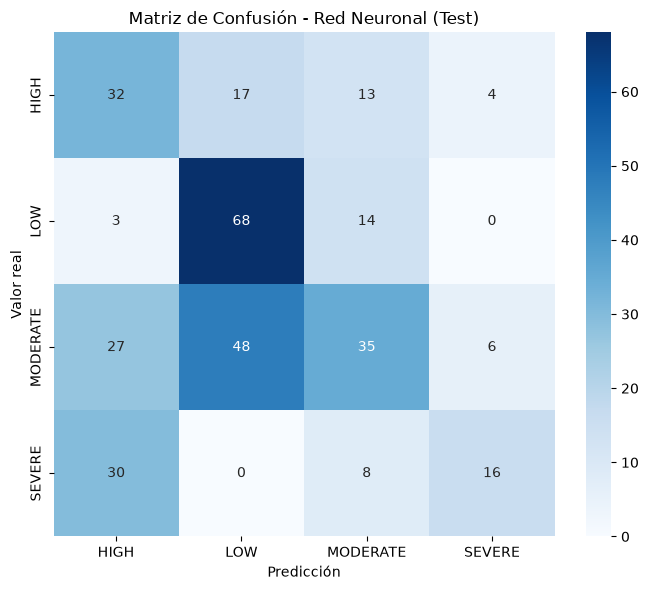

In [19]:
# ==========================================
# 8. PREDICCIONES SOBRE TEST
# ==========================================

best_model.eval()

with torch.no_grad():

    test_logits = best_model(X_test_tensor)

    # Obtener la clase con mayor probabilidad
    y_pred_tensor = torch.argmax(
        test_logits,
        dim=1
    )


# Convertimos a NumPy
y_pred = y_pred_tensor.numpy()

y_test_np = y_test_tensor.numpy()


# ==========================================
# 9. MÉTRICAS
# ==========================================

accuracy = accuracy_score(
    y_test_np,
    y_pred
)

precision = precision_score(
    y_test_np,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test_np,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test_np,
    y_pred,
    average='weighted'
)


# ==========================================
# 10. MOSTRAR MÉTRICAS
# ==========================================

print("\n==============================================")
print("       MÉTRICAS EN TEST (RED NEURONAL)")
print("==============================================")

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")

print()


# ==========================================
# 11. CLASSIFICATION REPORT
# ==========================================

print("==============================================")
print("              CLASSIFICATION REPORT")
print("==============================================")

print(
    classification_report(
        y_test_np,
        y_pred,
        target_names=le.classes_
    )
)


# ==========================================
# 12. MATRIZ DE CONFUSIÓN
# ==========================================

cm = confusion_matrix(
    y_test_np,
    y_pred
)


plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.title(
    'Matriz de Confusión - Red Neuronal (Test)'
)

plt.tight_layout()

plt.show()